# Diffusion on the edge - Part II: Maximal manifold exploration

In the previous part, we explored the basics of score-matching based diffusion models and continous-time stochastic processes.  
This follow up piece will walk through the basic ideas explored in the paper _Provable Maximum Entropy Manifold Exploration via Diffusion Models_ by De Santi et al.

## Main concept

The paper introduces the concept of exploring the data manifold maximally by fine tuning a pre-learned diffusion model. Mathematically, the paper describes how diffusion models can miss some of the underlying data distribution. Our goal is to implement the described S-MEME algorithm and generate samples from low-density regions of the data manifold.

## Dataset

For simplicity, as we develop this implementation code we should have a simple and robust dataset on hand. 

Let's take as our fundamental data manifold all possible 2D-triangles based on distance. So each data point is a triplet of numbers, $(a, b, c)$ where the measurements $a, b, c$ are distances between points $A, B, C$ defined as $a = |AB|, b = |BC|, c = |CA|$. All of these points lie on some non-trivial submanifold of $\mathbb{R}^3$. For simplicity, let's also constrict the distances to be less than $1$. Therefore, the possible data points lie as a subset of the unit cube, $(a, b, c) \in [0, 1]^3$. Furthermore, let always be true that $a \leq b \leq c$, so we maintain an order on the sides.

## Transformations

We will utilize some transformations for the raw side lengths

- Side normalized $(a, b, c) = (a / c, b / c, 1)$
- Perimeter normalized $(a, b, c) = (a / l, b / l, c / l)$ where $l = a + b + c$

For training neural networks, we do a mean and standard deviation scaling as well, on top of these two normalization approaches.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns

from diffusion_on_the_edge.core.grid import TimeGrid
from diffusion_on_the_edge.processes import OUTorchParams, OUTorch
from diffusion_on_the_edge.data.ou_dataset import OUDiffusionDatasetVectorized
from diffusion_on_the_edge.data.triangle_dataset import DatasetOptions, generate_triangle_dataset, dataset_from_sides
from diffusion_on_the_edge.modeling.model import SimpleScoreNet
from diffusion_on_the_edge.modeling.training import train_scorenet, TrainConfig
from diffusion_on_the_edge.sde.torch_backend import reverse_pc_sampler_torch
from diffusion_on_the_edge.modeling.tuning_model import build_teacher_student

ASSETS_FOLDER = './assets'

In [2]:
# Dataset sizes
B, D = 1024, 3
ou_params = OUTorchParams(dim = 4, theta = 0.3, sigma = 0.5)
grid = TimeGrid(t0 = 0, t1 = 1, N = 101)
dataset_params = DatasetOptions(
    n_samples=B,
    side_bias={'equilateral': 0.00, 'isosceles': 0.05, 'scalene': 0.95},
    angle_bias={'right': 0.00, 'acute': 0.90, 'obtuse': 0.1},
)

In [3]:
# Generate dataset with both side and angle biases
dataset_df = generate_triangle_dataset(dataset_params)
dataset_df.head()

,a,b,c,side_type,angle_type,angle_A_deg,angle_B_deg,angle_C_deg,perimeter,area,a_over_c,b_over_c,x,y,a_over_l,b_over_l,c_over_l
0,0.376802,0.390557,0.534150,scalene,acute,44.835878,46.954934,88.209188,1.301509,0.073545,0.705423,0.731174,0.257195,0.275373,0.289512,0.300080,0.410408
1,0.188496,0.494622,0.496998,scalene,acute,21.914174,78.333841,79.751985,1.180116,0.045873,0.379268,0.995219,0.038115,0.184602,0.159726,0.419130,0.421144
2,0.573584,0.795410,0.957273,scalene,acute,36.758696,56.087156,87.154148,2.326267,0.227836,0.599185,0.830912,0.320020,0.476010,0.246568,0.341925,0.411506
3,0.801615,0.821972,0.932127,scalene,acute,53.944037,55.993345,70.062617,2.555715,0.309707,0.859985,0.881824,0.448335,0.664517,0.313656,0.321621,0.364723
4,0.713944,0.818943,0.880056,scalene,acute,49.535806,60.774273,69.689922,2.412943,0.274164,0.811249,0.930558,0.348584,0.623061,0.295881,0.339396,0.364723


Next, we can take a look at our generated dataset of triangles.

In [4]:
import matplotlib.pyplot as plt

def plot_triangle(a, b, c, ax, label=None, color='blue'):
    """
    Plot a triangle in 2D given side lengths a, b, c.
    Triangle ABC with:
        A at (0, 0),
        B at (c, 0),
        C determined by cosine law from a, b, c
    """
    # Fixed base AB
    A = np.array([0, 0])
    B = np.array([c, 0])
    
    # Use law of cosines to find angle at C
    cos_angle = (a**2 + c**2 - b**2) / (2 * a * c)
    cos_angle = np.clip(cos_angle, -1, 1)  # numerical safety
    angle = np.arccos(cos_angle)
    # Coordinates of C using polar transformation from A
    C = np.array([a * np.cos(angle), a * np.sin(angle)])
    triangle = np.array([A, B, C, A])
    ax.plot(triangle[:, 0], triangle[:, 1], marker='o', color=color, label=label, alpha = 0.7)
    ax.set_aspect('equal')

def visualize_sample_triangles(df, n=5):
    """
    Visualize n triangles from the dataframe.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    sample: pd.DataFrame = df.sample(n=n).reset_index()
    colors = plt.cm.viridis(np.linspace(0, 1, n))
    
    for i, row in sample.iterrows():
        a, b, c = row.a, row.b, row.c # Assumes first three are the sides
        plot_triangle(a, b, c, ax, label=f"{row.side_type}, {row.angle_type}", color=colors[i])
    
    ax.legend()
    return fig, ax

In [31]:
# Visualize a few triangles
fig, ax = visualize_sample_triangles(dataset_df, n=5)
ax.grid()
ax.set_title('Triangles in 2-dimensions')
fig.savefig(f'{ASSETS_FOLDER}/triangle_plot.png')
plt.close()

<img src='./assets/triangle_plot.png'></img>

Our dataset contains normalized side lengths as well, below is a plot of the perimeter scaled versions.

Text(0.5, 1.0, 'Perimeter scaled triangles')

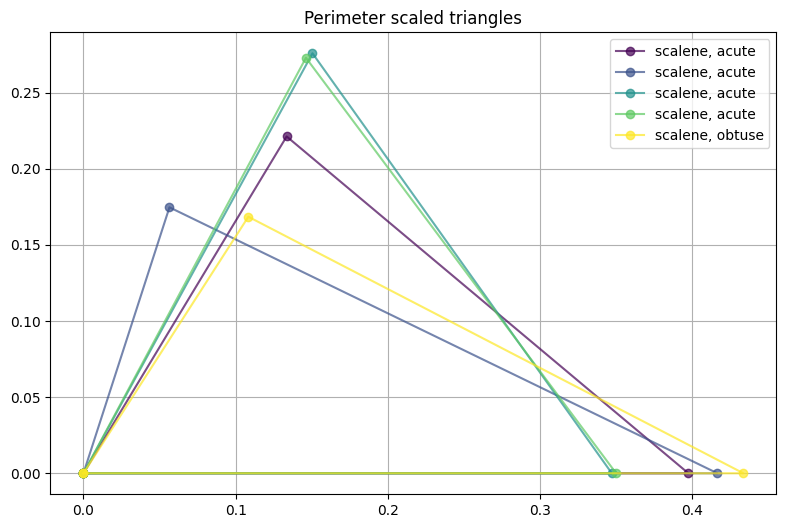

In [6]:
# Plotting perimeter normalized triangles
plotting_df = dataset_df[['a_over_l', 'b_over_l', 'c_over_l', 'side_type', 'angle_type']].rename({'a_over_l': 'a', 'b_over_l': 'b', 'c_over_l': 'c'}, axis = 1)
fig, ax = visualize_sample_triangles(plotting_df)
ax.grid()
ax.set_title('Perimeter scaled triangles')

# Modeling

We create a $4$-dimensional OU diffusion process with specific $\lambda$ and $\sigma$ parameters, as described in the first part. Alongside it, we create a neural network model to be our first training model.

In [7]:
ou_process = OUTorch(ou_params)

In [8]:
model = SimpleScoreNet(input_dimension=4, layer_count=4, hidden_dim=256)

Now we define an iterable dataset for the diffusion model, the dataset contains tuples $(X, t, \nabla_x p_t(x))$.

In other words, the iterable dataset generates samples $x \sim X_t$ from the diffusion process from the starting set of triangles. Alonside the samples, we compute the correct value for the gradient of the density $p_t(x)$. We use the normalized side lengths and provide the perimeter as an additional feature $X = (a / l, b / l, c / l, l)$. After the perimeter normalization, we also compute the mean and standard deviation, and use them as a second normalization step for the network.

In [9]:
scaled_dataset = dataset_df[['a_over_l', 'b_over_l', 'c_over_l', 'perimeter']].to_numpy()
scaled_dataset_torch = torch.from_numpy(scaled_dataset)
means = scaled_dataset_torch.mean(dim = 0)
stds = scaled_dataset_torch.std(dim = 0)
scaled_dataset_torch = (scaled_dataset_torch - means) / stds

print(scaled_dataset_torch.max())
print(scaled_dataset_torch.min())
print(scaled_dataset_torch.mean())


dataset = OUDiffusionDatasetVectorized(
    ou_process,
    x0_pool=scaled_dataset_torch,
    T_max=grid.t1,
    batch_size=32,
    batches_per_epoch=100
)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=None)

tensor(3.5912, dtype=torch.float64)
tensor(-3.7140, dtype=torch.float64)
tensor(1.3531e-16, dtype=torch.float64)


In [10]:
# Train the scoring model on the triangle dataset
config = TrainConfig(epochs=16, lr=0.01)
train_result = train_scorenet(model, dataloader, cfg=config)
train_result

Epoch 1/16: 100it [00:00, 473.13it/s, loss=9.83]
Epoch 2/16: 100it [00:00, 777.25it/s, loss=8.88]
Epoch 3/16: 100it [00:00, 778.51it/s, loss=7.23]
Epoch 4/16: 100it [00:00, 728.68it/s, loss=6.71]
Epoch 5/16: 100it [00:00, 764.74it/s, loss=6.85]
Epoch 6/16: 100it [00:00, 782.14it/s, loss=6.59]
Epoch 7/16: 100it [00:00, 783.31it/s, loss=6.36]
Epoch 8/16: 100it [00:00, 778.21it/s, loss=6.36]
Epoch 9/16: 100it [00:00, 776.76it/s, loss=6.29]
Epoch 10/16: 100it [00:00, 775.99it/s, loss=6.41]
Epoch 11/16: 100it [00:00, 775.75it/s, loss=6.4]
Epoch 12/16: 100it [00:00, 766.80it/s, loss=6.36]
Epoch 13/16: 100it [00:00, 779.52it/s, loss=6.03]
Epoch 14/16: 100it [00:00, 775.86it/s, loss=6.34]
Epoch 15/16: 100it [00:00, 777.78it/s, loss=6.29]
Epoch 16/16: 100it [00:00, 773.98it/s, loss=6.35]


{'model': SimpleScoreNet(
   (time_emb): SinusoidalTimeEmbedding()
   (net): Sequential(
     (0): Linear(in_features=68, out_features=256, bias=True)
     (1): ReLU(inplace=True)
     (2): Linear(in_features=256, out_features=256, bias=True)
     (3): ReLU(inplace=True)
     (4): Linear(in_features=256, out_features=256, bias=True)
     (5): ReLU(inplace=True)
     (6): Linear(in_features=256, out_features=256, bias=True)
     (7): ReLU(inplace=True)
     (8): Linear(in_features=256, out_features=4, bias=True)
   )
 ),
 'losses': [9.831674518585205,
  8.875641875267029,
  7.230103254318237,
  6.708644905090332,
  6.852216730117798,
  6.594032688140869,
  6.36336841583252,
  6.358727502822876,
  6.288545458316803,
  6.413940625190735,
  6.402638936042786,
  6.364014232158661,
  6.027213461399079,
  6.342818851470947,
  6.288363084793091,
  6.352544288635254]}

### Backwards sampling

Now we have the model, we can sample backwards as in the introduction post.

In [11]:

# Generate random samples
x_T = torch.randn(B, D + 1).to('cpu')

# Get the trained model and put in 'eval' mode.
score_model: nn.Module = train_result.get('model')
score_model.to('cpu').eval()

# Generate new samples using backwards SDE
samples = reverse_pc_sampler_torch(
    x_T=x_T,
    process=ou_process,
    score_model=score_model,
    grid = grid,
    snr=0.15,
)

# Transform back from perimeter scaled values
transformed_samples = samples * stds + means
samples_arr = transformed_samples.detach().cpu().numpy()
samples_arr = samples_arr[:, :3] * samples_arr[:, 3].reshape(-1, 1)

In [12]:
generation_options = DatasetOptions(include_geometry=True, include_normalized_sides=True, include_perimeter_normalized_sides=False, include_planar_embedding=False)
generated_df = dataset_from_sides(samples_arr, generation_options)
generated_df['is_valid_triangle'].value_counts(normalize=True)

is_valid_triangle
True     0.96875
False    0.03125
Name: proportion, dtype: float64

### Original model conclusion

Now we have a model with sufficient capability of generating valid triangles with an excellent accuracy. We can take a look at some of the samples we generated.

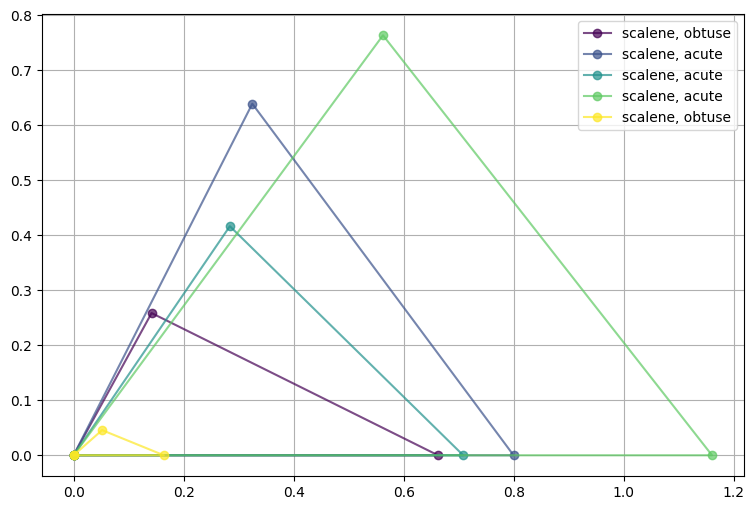

In [13]:
fig, ax = visualize_sample_triangles(generated_df[generated_df['is_valid_triangle']])
ax.grid()

From the above plot, we can see that our model has generated some nice triangles for us.  
We can also take a look at the invalid samples and see where they went wrong.

(<Figure size 1200x600 with 1 Axes>, <Axes: >)

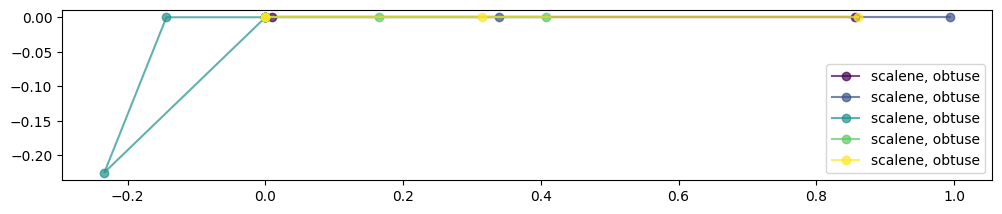

In [14]:
visualize_sample_triangles(generated_df[~generated_df['is_valid_triangle']], n = 5)

Easily we can see that some of the samples are either degenerate with some side being approximately $0$, or they break the boundary length of $1$.

# Maximal manifold exploration

Now we have the basic setup ready, we have a pretuned model $s^\text{pre}$ which is capable of generating valid triangles.  
Turning our attention to the manifold $\mathcal{T}$, we have the goal of exploring some of the uncommon triangles and seeing if we can find some quite niche samples.

## Maximal exploration formalism

The punchline of the paper is the following: we can fine-tune an already trained model $s^\text{pre}$ to find those uncommon samples by adjusting the model. More formally, given a pre-learned model (policy) $\pi^\text{pre}$, we want to learn a new model $\pi$ such that

$$
\begin{align}
\pi &= \arg\max_{\pi} \ \mathcal{H}(p^\pi_T) \\
p^{\pi}_T &\in \mathbb{P}(\Omega_\text{pre}) \\
\end{align}
$$

is satisfied. Here $\mathcal{H}(p^\pi_T)$ denotes the entropy of the marginal density $p^\pi_T$, and the constraint ensures that $p^\pi_T$ lies within the support $\Omega_\text{pre}$ of the original pre-trained model’s distribution.

In essence, this captures the idea of learning a distribution that maximizes entropy—spreading probability mass as uniformly as possible—while remaining within the “valid” region $\Omega_\text{pre}$ defined by the pre-trained model.

## The first variation and surprise

Optimizing entropy directly is difficult since it is a nonlinear functional of the distribution.   
The key insight of the paper is to look at the first variation of entropy, which is linear and therefore tractable. The entropy variation evaluated at the pre-trained distribution is 

$$\delta \mathcal{H}(p^\text{pre}_T)(x) = -\log p^\text{pre}_T(x)$$

which can be interpreted as a surprise signal. 
The variation makes it so samples that were unlikely under the original model are weighted highly. Thus, the fine-tuning problem can be rewritten as

$$
\pi^\ast = \arg\max_{\pi} \ \mathbb{E}_{x \sim \pi}\big[ -\log p^\text{pre}_T(x) \big] \ - \ \alpha \, D_{\text{KL}}\!\left(p^\pi_T \;\|\; p^\text{pre}_T \right),
$$

where the Kullback–Leibler regularization, $D_{\text{KL}}$, ensures that the fine-tuned policy does not drift too far and remains supported on $\Omega_\text{pre}$.

### Optional background: functionals and variations

In general, a variation is a concept from (surprise, surprise) *calculus of variations*. It is a generalization of the derivative, but instead of taking derivatives of functions, we take derivatives of functionals. A functional is a map from a space of functions into the real numbers, $\mathcal{F}: \mathcal{X} \to \mathbb{R}$ where $f \in \mathcal{X} \mapsto \mathcal{F}(f) \in \mathbb{R}$.

For example, evaluating a definite integral of an integrable function $f$ is a functional, $\mathcal{F}[f] = \int_a^b f(x)dx$. The first variation of $\mathcal{F}$ at $f$ in the direction of a perturbation $\eta(x)$ is defined as

$$
\delta \mathcal{F}[f; \eta] 
= \left.\frac{d}{d\epsilon} \, \mathcal{F}[f + \epsilon \eta] \right|_{\epsilon = 0}.
$$

Here $\epsilon$ is a small parameter which acts as the strength of the disturbance. Like with directional derivatives in multivariate calculus, this is exactly the infinite-dimensional analogue.


## The crucial realization: no density estimation needed

Naively, the process of entropy maximization would require estimating $p^\text{pre}_T(x)$, which is infeasible in high dimensions. The breakthrough of the paper is recognizing that the gradient of the entropy variation is exactly equal to the negative score

$$
\nabla_x \delta \mathcal{H}(p^\pi_T) \;=\; - \nabla_x \log p^\pi_T(x) \;\approx\; - s^\pi(x, T),
$$

where $s^\pi$ is the score function. For more details, please refer to the original paper _paper name here_.

This means that instead of explicitly computing densities, we can use the score network itself to provide the update direction for entropy maximization. Fine-tuning reduces to an iterative process where the pre-trained score model supplies the gradient information needed to explore low-density regions.


## Implementation of manifold exploration in practice

The practical implementation of the fine tuning approach is done by having a loss function, with $2$ different components
- close distance $(\Delta s_k(x, t))^2$ 
- tuning to direction of negative score $\left<\Delta s_k(x, T), -s_{k - 1}(x, T)\right>$

where $\Delta s_k(x, t) = s_{k}(x, t) - s_{k - 1}(x, t)$.

Adding these different loss components we obtain the total loss which is then minimized in a "student & teacher"-style mirror gradient-descent algorithm. The previous outer iteration model $s_{k - 1}$ is the teacher and the current model $s_k$ is the student. The loss function which we optimize is something like this

$$
\mathcal{L} = (\Delta s_k(x, t))^2 - \left<\Delta s_k(x, T), -s_{k - 1}(x, T)\right>
$$

which balances the distance from the original model and the tuning direction at near the end of the sample generation process. In practice, we optimize this loss using a batched gradient descent and the direction term is taken over samples where $t > (T - \epsilon)$ for some appropriate $\epsilon > 0$.



In [15]:
teacher_tuning, student_tuning = build_teacher_student(pretrained_score_model=score_model, d = 4, hidden_size=64)

In [16]:
INNER_EPOCHS = 10
OUTER_EPOCHS = 5

beta = 5.0
lambda_prox = 0.001

BATCH_SIZE = 32
DATASET_SIZE = 2 ** 10

def is_valid_triangle_torch(x_prescaled: torch.Tensor):
    x = (x_prescaled + 1) / 2
    a, b, c = torch.sort(x, dim=1).values.unbind(dim=1)
    return (a + b > c) & (a + c > b) & (b + c > a)

optimizer = torch.optim.AdamW(student_tuning.delta.parameters(), lr = 0.0001)

# Tuning loop
for epoch in range(OUTER_EPOCHS):
    # Generate new samples using score model
    x_T = torch.randn(size=(DATASET_SIZE, 4))
    with torch.no_grad():
        samples = reverse_pc_sampler_torch(
            x_T=x_T,
            process=ou_process,
            score_model=student_tuning,
            grid=grid,
            snr=0.15,
        )

        inverse_normalized = stds * samples + means # Inverse the normalization
    
    raw_lengths = inverse_normalized[:, :3] * inverse_normalized[:, [3]]
    # Check valid triangles
    validity_result = is_valid_triangle_torch(x_prescaled=raw_lengths)
    valid_samples = samples[validity_result]

    generated_dataset = OUDiffusionDatasetVectorized(
        process=ou_process,
        x0_pool=valid_samples.detach(),
        T_max=grid.t1,
        batch_size=BATCH_SIZE,
        batches_per_epoch=max(1, valid_samples.shape[0] // BATCH_SIZE),
    )
    
    generated_dataloader = torch.utils.data.DataLoader(generated_dataset, batch_size=None)
    teacher_tuning.load_state_dict(student_tuning.state_dict())
    teacher_tuning.eval()
    student_tuning.train()

    # Inner loop
    losses = []
    for inner_epoch in range(INNER_EPOCHS):
        for batch in generated_dataloader:
            optimizer.zero_grad()

            # Get training elements
            t = batch.get('t')
            x = batch.get('xt')
            score = batch.get('score')

            # Obtain a weight for the smallest t (corresponding to close the original data distribution)
            w_T = (t <= 0.1 * grid.t1).float()

            # Forward pass to tuning models
            student_prediction = student_tuning(x, t)
            with torch.no_grad():
                teacher_prediction = teacher_tuning(x, t)

            delta = student_prediction - teacher_prediction
            delta_loss = lambda_prox * torch.sum(delta ** 2, dim = 1).mean()

            # Direction loss
            dir_term = (-teacher_prediction * delta).sum(dim = 1)
            direction_loss = (beta * dir_term * w_T).mean()
            loss = delta_loss - direction_loss
            loss.backward()
            optimizer.step()

            losses.append([x_.detach().cpu().numpy() for x_ in [loss, delta_loss, direction_loss]])

    losses = np.asarray(losses)

## Fine-tuned model sampling

Now we have a fine-tuned model $\pi^*$. Utilizing it, we can sample now triangles which are underreprensented or even not found at all in the original dataset.

We begin by sampling from the tuned dataset and examining how many of our new samples are valid.

In [17]:
samples_tuned = reverse_pc_sampler_torch(
    x_T=x_T, # Note: We use the same input sample as the original model
    process=ou_process,
    score_model=student_tuning,
    grid=grid,
    snr=0.15,
) 
samples_tuned = samples_tuned * stds + means
samples_arr_tuned = samples_tuned.detach().cpu().numpy()

In [18]:
student_generated = dataset_from_sides(samples_arr_tuned[:, :3] * samples_arr_tuned[:, [3]], generation_options)
student_generated['is_valid_triangle'].value_counts(normalize=True)

is_valid_triangle
True     0.958008
False    0.041992
Name: proportion, dtype: float64

We have generated again some invalid samples. However, as we will soon see, this tradeoff is quite nice since we obtain some uncommon, but valid samples.

### Visualization

We have a nice proportion of valid triangles, we can visualize them in a similar way.  
By creating a mapping from the side lengths $(a, b, c)$ into a shape $(u, v, 1)$ by a simple transformation, $u = x/c, v = y/c$, we can visualize the space of triangles as a submanifold of $\mathbb{R}^2$. 

The score fields themselves can also be visualized, noting how different the original model is from the fine-tuned one.

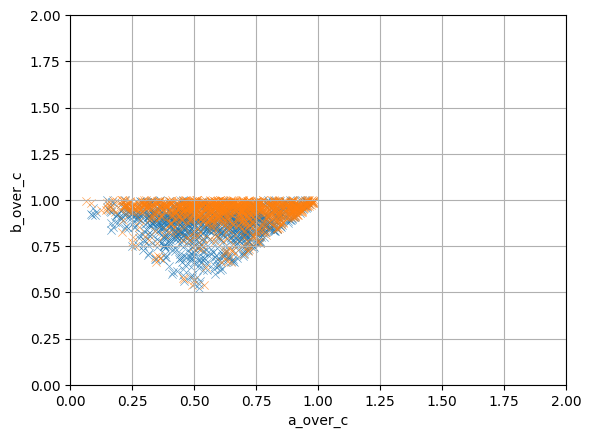

In [19]:
sns.scatterplot(generated_df[generated_df['is_valid_triangle']], x = 'a_over_c', y = 'b_over_c', alpha=0.7, marker='x').set(xlim=(0, 2), ylim=(0, 2), alpha = 0.3)
sns.scatterplot(student_generated[student_generated['is_valid_triangle']], x = 'a_over_c', y = 'b_over_c', alpha=0.7, marker='x').set(xlim=(0, 2), ylim=(0, 2), alpha = 0.3)
plt.grid()

### Qualitative values

We can also examine the qualitative differences between the fine-tuned and original diffusion models.

In [20]:
comparison_dfs = [student_generated, generated_df]
side_types_df = pd.concat([df['side_type'].value_counts(normalize=True) for df in comparison_dfs], axis = 1).fillna(0)
side_types_df.columns = ["student", "original"]
side_types_df

,student,original
side_type,,
scalene,0.961914,0.991211
isosceles,0.036133,0.008789
equilateral,0.001953,0.000000


In [21]:
angle_types_df = pd.concat([df['angle_type'].value_counts(normalize=True) for df in comparison_dfs], axis = 1).fillna(0)
angle_types_df.columns = ["student", "original"]
angle_types_df

,student,original
angle_type,,
acute,0.879883,0.604492
obtuse,0.119141,0.391602
right,0.000977,0.003906


## Density approximation

In [22]:
from diffusion_on_the_edge.sde.torch_backend import pf_logp_from_x0

In [23]:
density_prior_variance = float((ou_params.sigma ** 2) / (2 * ou_params.theta) * (1 - np.exp(-2 * ou_params.theta * grid.t1))) # T = 1.0
density_prior_variance

0.187995151627489

In [24]:
def make_uv_heatmap_with_pfode(
    score_model,
    ou_process,
    prior_variance,                 # your OU prior at T
    timegrid,
    u_range=(-1.0, 1.0), v_range=(-1.0, 1.0),
    res=40, 
    n_probe=2,
    c=1.0,
    mask_fn=None,                  # e.g., triangle inequality in (u,v)
):
    import numpy as np, torch
    us = np.linspace(*u_range, res)
    vs = np.linspace(*v_range, res)
    U, V = np.meshgrid(us, vs, indexing="xy")

    # Map (u,v) -> (x,y,z) with z=c
    xyz = np.stack([c*U.ravel(), c*V.ravel(), np.full(U.size, c)], axis=-1)
    perimeter = np.sum(xyz, axis = 1, keepdims=True)
    xyzp = np.hstack([xyz, perimeter])
    x0 = torch.tensor(xyzp, dtype=torch.float)

    logp0 = pf_logp_from_x0(
        x0, ou_process, score_model, prior_variance,
        grid=timegrid, n_probe=n_probe
    ).detach().cpu().numpy().reshape(res, res)

    # Optional: apply mask in UV-space
    if mask_fn is not None:
        M = mask_fn(U, V)   # boolean mask of shape (res,res)
        logp0 = np.where(M, logp0, np.nan)

    return logp0, us, vs

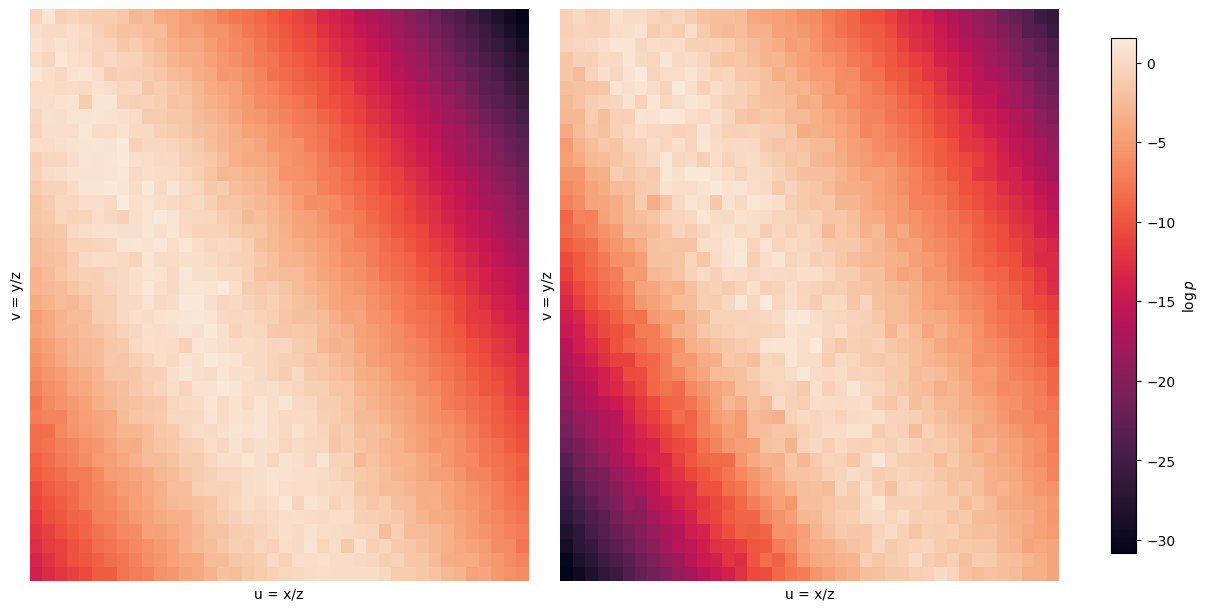

In [25]:
plotting_c = 0.2
logp, _, _ = make_uv_heatmap_with_pfode(score_model, ou_process, density_prior_variance, timegrid=grid, c = plotting_c)
logp_student, _, _ = make_uv_heatmap_with_pfode(student_tuning, ou_process, density_prior_variance, timegrid=grid, c = plotting_c)

fig, ax = plt.subplots(1, 2, figsize=(12,6), constrained_layout=True)
original_map = sns.heatmap(
    logp,
    ax=ax[0],
    cbar=False,
    mask=np.isnan(logp) if 'logp' in locals() else None,  # or mask=~mask
    xticklabels=False, yticklabels=False  # turn off if res is large
)
ax[0].set_xlabel("u = x/z")
ax[0].set_ylabel("v = y/z")
ax[0].invert_yaxis()

student_map = sns.heatmap(
    logp_student,
    ax=ax[1],
    cbar=False,
    mask=np.isnan(logp) if 'logp' in locals() else None,
    xticklabels=False, 
    yticklabels=False
)
ax[1].set_xlabel("u = x/z")
ax[1].set_ylabel("v = y/z")
ax[1].invert_yaxis()

cbar = fig.colorbar(original_map.collections[0], ax=ax, location="right", shrink=0.9)
cbar.set_label("$\\log p$")
plt.show()

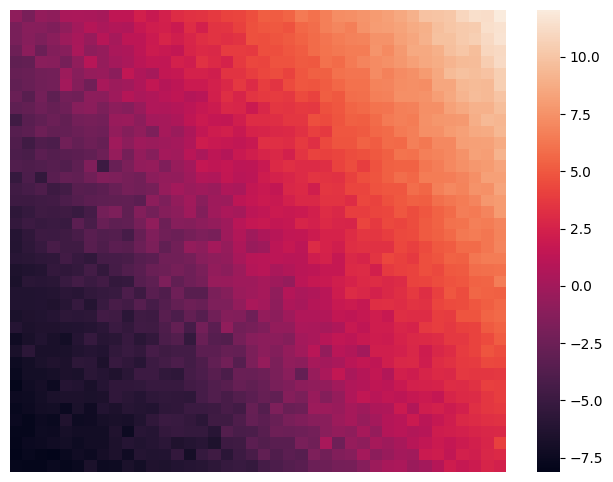

In [26]:
difference_map = logp_student - logp
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    difference_map,
    ax = ax,
    xticklabels=False,
    yticklabels=False
)

ax.invert_yaxis()

The above picture displays nicely the effect of our entropy increasing fine tuning. We can clearly see how the middle sections, which are well-covered by the original diffusion model, has 